### Stock Market Prediction And Forecasting Using Stacked LSTM

In [1]:
### Keras and Tensorflow >2.0

In [81]:
import pandas as pd
from stock_data_analyser import *
sda= StockDataAnalyser(stock_symbol='MSFT')
sda.fetch_from_db()
df=sda.stock_data


In [82]:
df.head()

,index,Open,High,Low,Close,Volume,EMA,Bollinger_Upper,Bollinger_Lower,Close_Lag1,...,Close_Lag12,Close_Lag13,Close_Lag14,Close_Lag15,Close_Lag16,Close_Lag17,Close_Lag18,Close_Lag19,Trend,Stock_name
0,2025-03-18,387.070,387.3700,381.1000,383.52,19486850,384.445883,405.269889,357.752111,388.70,...,396.99,392.53,399.73,397.90,404.00,408.21,416.13,414.77,NaN,MSFT
1,2025-03-17,386.700,392.7050,385.5700,388.70,22474272,384.851037,405.367339,357.743661,388.56,...,392.53,399.73,397.90,404.00,408.21,416.13,414.77,409.64,NaN,MSFT
2,2025-03-14,379.775,390.2300,379.5100,388.56,19952846,385.204272,405.379594,357.742406,378.77,...,399.73,397.90,404.00,408.21,416.13,414.77,409.64,408.43,NaN,MSFT
3,2025-03-13,383.155,385.3200,377.4500,378.77,20473017,384.591484,405.283330,357.580670,383.27,...,397.90,404.00,408.21,416.13,414.77,409.64,408.43,410.54,NaN,MSFT
4,2025-03-12,382.950,385.2165,378.9507,383.27,24253567,384.465628,404.560897,357.581103,380.45,...,404.00,408.21,416.13,414.77,409.64,408.43,410.54,409.04,NaN,MSFT


In [83]:
df1=df['Close'][::-1].reset_index()['Close']

In [84]:
df1

0      261.15
1      261.55
2      261.97
3      254.56
4      252.51
        ...  
975    383.27
976    378.77
977    388.56
978    388.70
979    383.52
Name: Close, Length: 980, dtype: float64

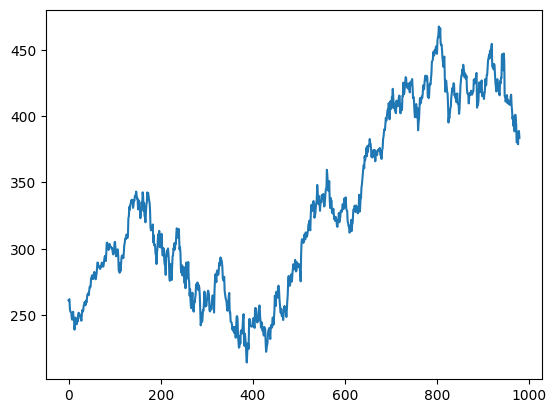

In [85]:
import matplotlib.pyplot as plt
plt.plot(df1)

In [ ]:
### LSTM are sensitive to the scale of the data. so we apply MinMax scaler 

In [75]:
import numpy as np

In [9]:
df1

0      261.15
1      261.55
2      261.97
3      254.56
4      252.51
        ...  
975    383.27
976    378.77
977    388.56
978    388.70
979    383.52
Name: Close, Length: 980, dtype: float64

In [86]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [ ]:
print(df1)

[[0.18514863]
 [0.18672772]
 [0.18838577]
 [0.15913308]
 [0.15104023]
 [0.14973748]
 [0.1484742 ]
 [0.13240693]
 [0.12719593]
 [0.14006553]
 [0.15084284]
 [0.12999882]
 [0.12624847]
 [0.09770637]
 [0.11361573]
 [0.13382812]
 [0.12210335]
 [0.11381311]
 [0.11397102]
 [0.1272354 ]
 [0.12206387]
 [0.14421065]
 [0.14792152]
 [0.14701354]
 [0.13840748]
 [0.13986815]
 [0.13086732]
 [0.13047254]
 [0.12419565]
 [0.14425013]
 [0.15617228]
 [0.15127709]
 [0.15530378]
 [0.169713  ]
 [0.17227903]
 [0.18017449]
 [0.17413446]
 [0.17026568]
 [0.1841617 ]
 [0.17835853]
 [0.19099128]
 [0.20236074]
 [0.20143303]
 [0.20701907]
 [0.20042636]
 [0.21503296]
 [0.22561289]
 [0.22363902]
 [0.22640243]
 [0.25028621]
 [0.25032569]
 [0.25928704]
 [0.24937823]
 [0.25143105]
 [0.24898346]
 [0.26343216]
 [0.26947219]
 [0.26362954]
 [0.26252418]
 [0.24775966]
 [0.25687892]
 [0.26509021]
 [0.28380246]
 [0.29773795]
 [0.29529036]
 [0.28538155]
 [0.28411827]
 [0.28522364]
 [0.27894675]
 [0.27859145]
 [0.28767123]
 [0.28

In [87]:
##splitting dataset into train and test split
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [12]:
test_size

343

In [13]:
training_size,test_size

(637, 343)

In [14]:
train_data

array([[0.18514863],
       [0.18672772],
       [0.18838577],
       [0.15913308],
       [0.15104023],
       [0.14973748],
       [0.1484742 ],
       [0.13240693],
       [0.12719593],
       [0.14006553],
       [0.15084284],
       [0.12999882],
       [0.12624847],
       [0.09770637],
       [0.11361573],
       [0.13382812],
       [0.12210335],
       [0.11381311],
       [0.11397102],
       [0.1272354 ],
       [0.12206387],
       [0.14421065],
       [0.14792152],
       [0.14701354],
       [0.13840748],
       [0.13986815],
       [0.13086732],
       [0.13047254],
       [0.12419565],
       [0.14425013],
       [0.15617228],
       [0.15127709],
       [0.15530378],
       [0.169713  ],
       [0.17227903],
       [0.18017449],
       [0.17413446],
       [0.17026568],
       [0.1841617 ],
       [0.17835853],
       [0.19099128],
       [0.20236074],
       [0.20143303],
       [0.20701907],
       [0.20042636],
       [0.21503296],
       [0.22561289],
       [0.223

In [99]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100 
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [100]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [43]:
print(X_train.shape)

(616, 20)


In [44]:
print(ytest.shape)

(322,)


In [45]:
print(X_test.shape), print(ytest.shape)

(322, 20)
(322,)


(None, None)

In [89]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [23]:
### Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

2025-04-16 13:23:25.944610: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-16 13:23:26.087421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744790006.132572    5421 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744790006.145724    5421 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744790006.273189    5421 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [90]:
model=Sequential()
model.add(LSTM(150,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(75,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')


/home/steeldev/Desktop/Github/PotatoTrade/mlenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 100, 150)       │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 75)        │        67,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        25,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,251 (719.73 KB)

 Trainable params: 184,251 (719.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=10,batch_size=64,verbose=1)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 241ms/step - loss: 0.0388 - val_loss: 0.1102
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - loss: 0.0078 - val_loss: 0.0226
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - loss: 0.0048 - val_loss: 0.0143
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - loss: 0.0037 - val_loss: 0.0247
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - loss: 0.0031 - val_loss: 0.0035
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - loss: 0.0025 - val_loss: 0.0055
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - loss: 0.0023 - val_loss: 0.0072
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - loss: 0.0024 - val_loss: 0.0034
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - loss: 0.0024 - val_loss: 0.0038
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - loss: 0.0024 - val_loss: 0.0042


In [27]:
import tensorflow as tf

In [ ]:
tf.__version__

'2.19.0'

In [92]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [93]:
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [79]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

288.0226761183479

In [53]:
### Test Data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

404.6527187568622

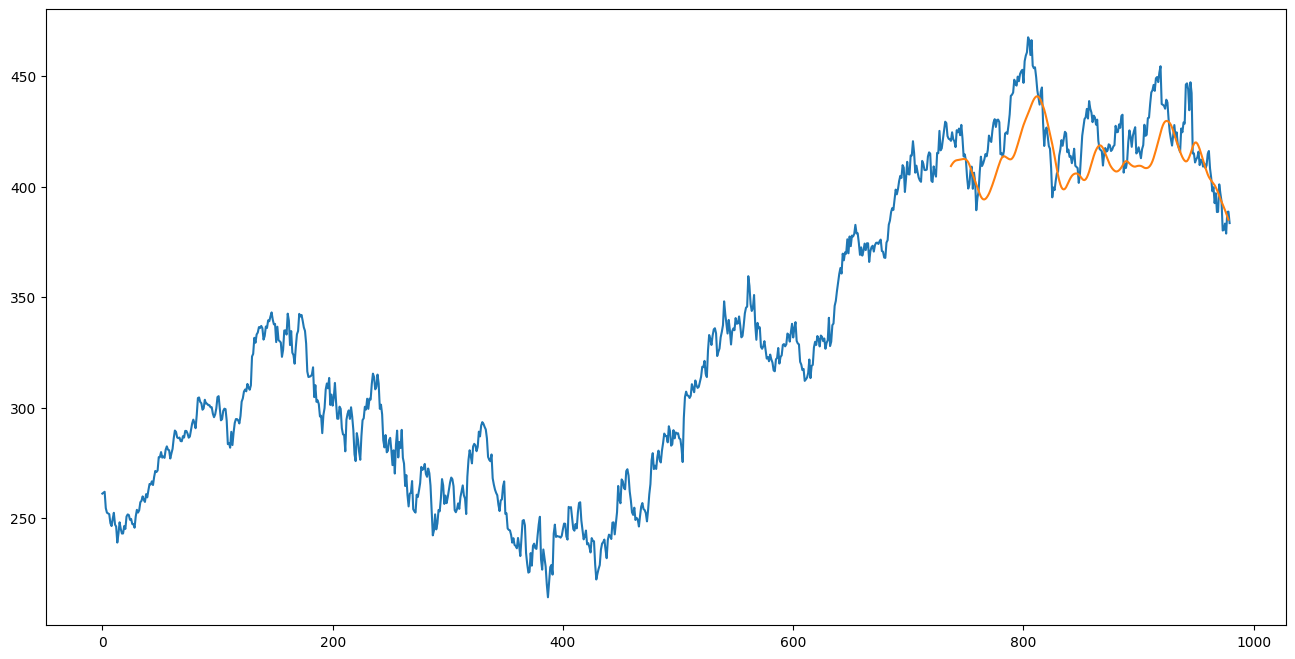

In [95]:
### Plotting 
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# plot baseline and predictions
plt.figure(figsize=(16,8))
plt.plot(scaler.inverse_transform(df1))
# plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [96]:
import plotly.graph_objects as go
import numpy as np

# Shift train predictions for plotting
look_back = 100
trainPredictPlot = np.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict) + look_back, :] = train_predict

# Shift test predictions for plotting
testPredictPlot = np.empty_like(df1)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict) + (look_back * 2) + 1:len(df1) - 1, :] = test_predict

# Create the plot
fig = go.Figure()

# Original data (inverse scaled)
fig.add_trace(go.Scatter(
    y=scaler.inverse_transform(df1).flatten(),
    mode='lines',
    name='Original Data'
))

# Train predictions
fig.add_trace(go.Scatter(
    y=trainPredictPlot.flatten(),
    mode='lines',
    name='Train Prediction',
    line=dict(dash='dot')
))

# Test predictions
fig.add_trace(go.Scatter(
    y=testPredictPlot.flatten(),
    mode='lines',
    name='Test Prediction',
    line=dict(dash='dash')
))

# Update layout
fig.update_layout(
    title='LSTM Predictions',
    xaxis_title='Time Step',
    yaxis_title='Value',
    width=1000,
    height=500
)

fig.show()


In [41]:
df.head()

,index,Open,High,Low,Close,Volume,EMA,Bollinger_Upper,Bollinger_Lower,Close_Lag1,...,Close_Lag12,Close_Lag13,Close_Lag14,Close_Lag15,Close_Lag16,Close_Lag17,Close_Lag18,Close_Lag19,Trend,Stock_name
0,2025-03-18,387.070,387.3700,381.1000,383.52,19486850,384.445883,405.269889,357.752111,388.70,...,396.99,392.53,399.73,397.90,404.00,408.21,416.13,414.77,NaN,MSFT
1,2025-03-17,386.700,392.7050,385.5700,388.70,22474272,384.851037,405.367339,357.743661,388.56,...,392.53,399.73,397.90,404.00,408.21,416.13,414.77,409.64,NaN,MSFT
2,2025-03-14,379.775,390.2300,379.5100,388.56,19952846,385.204272,405.379594,357.742406,378.77,...,399.73,397.90,404.00,408.21,416.13,414.77,409.64,408.43,NaN,MSFT
3,2025-03-13,383.155,385.3200,377.4500,378.77,20473017,384.591484,405.283330,357.580670,383.27,...,397.90,404.00,408.21,416.13,414.77,409.64,408.43,410.54,NaN,MSFT
4,2025-03-12,382.950,385.2165,378.9507,383.27,24253567,384.465628,404.560897,357.581103,380.45,...,404.00,408.21,416.13,414.77,409.64,408.43,410.54,409.04,NaN,MSFT


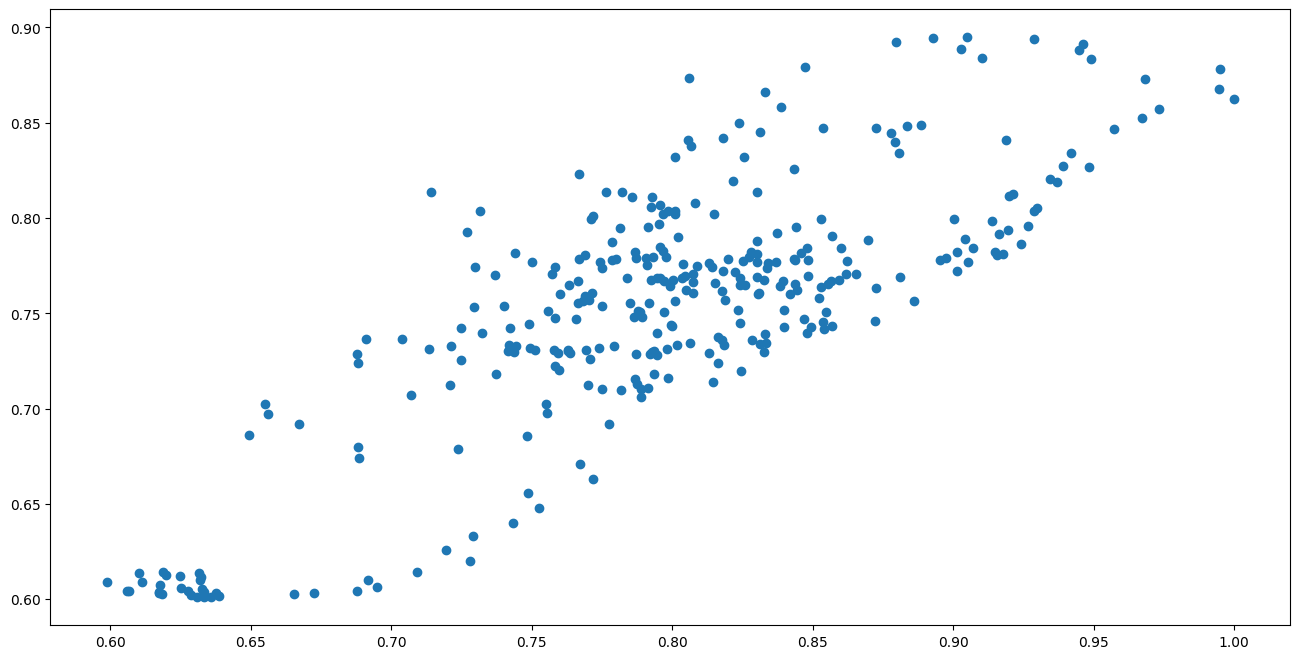

In [57]:
plt.figure(figsize=(16,8))
plt.scatter(ytest,scaler.transform(test_predict))
plt.show()

In [ ]:
len(test_data)

343

In [61]:
x_input=test_data[34:].reshape(1,-1)
x_input.shape


(1, 309)

In [62]:
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

In [63]:
temp_input

[0.6288342347321464,
 0.6329398760412143,
 0.6332556946034503,
 0.6309265327069596,
 0.6357032884607791,
 0.6387035648020213,
 0.61829379021752,
 0.6172279025699735,
 0.6067269353756265,
 0.6059768662903161,
 0.6333741265642888,
 0.6377166317950337,
 0.6652718013501241,
 0.6726145829221112,
 0.6877738739094391,
 0.6948797915597488,
 0.6917216059373891,
 0.7090916268603688,
 0.7280407405945285,
 0.7195136394141565,
 0.7289487189609568,
 0.7433974181832536,
 0.7525166791678181,
 0.7488058110615451,
 0.7716631795033754,
 0.7672022423117916,
 0.7237377126840628,
 0.7482136512573524,
 0.7775847775453003,
 0.7555959101496189,
 0.754964273025147,
 0.7887568591843984,
 0.7889937231060754,
 0.8144171173660731,
 0.7935336149382178,
 0.7582408906083454,
 0.7707552011369468,
 0.7591883462950534,
 0.7493190162251785,
 0.7443053965496821,
 0.7418972800126328,
 0.7792823023173184,
 0.7741107733607041,
 0.7630571236824445,
 0.7628202597607675,
 0.7637677154474755,
 0.7871382890529389,
 0.7944810706249

In [64]:
# demonstrate prediction for next 10 days
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):
    
    if(len(temp_input)>100):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1
    

print(lst_output)

0 day input [0.63293988 0.63325569 0.63092653 0.63570329 0.63870356 0.61829379
 0.6172279  0.60672694 0.60597687 0.63337413 0.63771663 0.6652718
 0.67261458 0.68777387 0.69487979 0.69172161 0.70909163 0.72804074
 0.71951364 0.72894872 0.74339742 0.75251668 0.74880581 0.77166318
 0.76720224 0.72373771 0.74821365 0.77758478 0.75559591 0.75496427
 0.78875686 0.78899372 0.81441712 0.79353361 0.75824089 0.7707552
 0.75918835 0.74931902 0.7443054  0.74189728 0.7792823  0.77411077
 0.76305712 0.76282026 0.76376772 0.78713829 0.79448107 0.79219139
 0.74375271 0.74154198 0.76937349 0.75784612 0.75113497 0.79361257
 0.79290198 0.83285303 0.79811298 0.80166594 0.81781217 0.8328925
 0.84923611 0.84674904 0.82353638 0.81875962 0.81789112 0.81508823
 0.830287   0.8179306  0.81402234 0.80387667 0.83403735 0.83036595
 0.83703762 0.82511547 0.84355138 0.81974656 0.78713829 0.79084916
 0.78003237 0.75014804 0.72981722 0.73708105 0.76317556 0.76905768
 0.7295014  0.75824089 0.74217362 0.69116892 0.713315

ValueError: cannot reshape array of size 308 into shape (1,100,1)

In [ ]:
day_new=np.arange(1,101)
day_pred=np.arange(101,131)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
len(df1)

1258

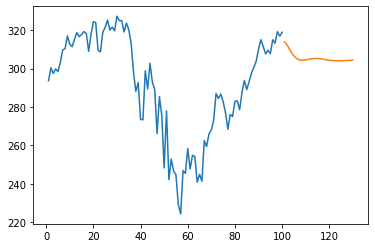

In [ ]:
plt.plot(day_new,scaler.inverse_transform(df1[1158:]))
plt.plot(day_pred,scaler.inverse_transform(lst_output))

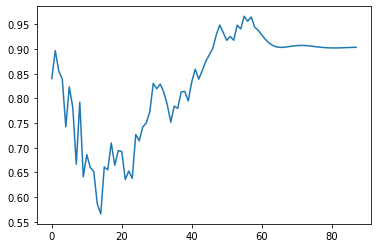

In [ ]:
df3=df1.tolist()
df3.extend(lst_output)
plt.plot(df3[1200:])

In [ ]:
df3=scaler.inverse_transform(df3).tolist()

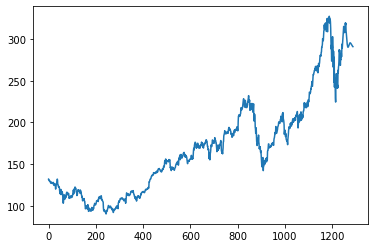

In [ ]:
plt.plot(df3)